## DSC540-T301 Data Preparation (2265-1)

Weeks 5 and 6 Assignments

Due on 4/26/2026

Paula Iman

References:

DigitalOcean (2025, June 25). Python open() Function Explained: How to Open, Read, and Write Files. Retrieved March 18, 2026, from https://www.digitalocean.com/community/tutorials/python-read-file-open-write-delete-copy

Lipp, B., Roychowdhury, S., & Sarkar, T. (2020). The data wrangling workshop (2nd ed.). Packt Publishing Ltd. McKinney, W. (2022). Python for data analysis: Data wrangling with pandas, NumPy, and Jupyter (3rd ed.). O'Reilly Media, Inc.

### Activity 5.01: Reading Tabular Data from a Web Page and Creating DataFrames

In [115]:
from bs4 import BeautifulSoup
import pandas as pd

 1. Open the page in a separate Chome tab and use inspect Element to view the source
 
 I opened the website and accessed the source code. I found tabs for header, body, and tables. 

In [116]:
# 2. Read the page using bs4
# Define the path to your fresh dataset
file_path = "The-Data-Wrangling-Workshop-master/Chapter05/datasets/List of countries by GDP (nominal) - Wikipedia.htm"

In [117]:
# Reading the page using bs4. I am also using the filepath set above. 
with open(file_path, 'r', encoding='utf-8') as fd:
    soup = BeautifulSoup(fd, 'html.parser')
    fd.close()


In [118]:
# Finding the table type
data_table = soup.find("table", {"class": '"wikitable"|}'})
print(type(data_table))

<class 'bs4.element.Tag'>


In [119]:
# 3 How many tables are in the file
all_tables = soup.find_all("table")
ntables = len(all_tables)
print(f"Total number of tables is {ntables} ")

Total number of tables is 9 


In [120]:
# 4.Find the rigth table using bs4.
# Focusng on finding tables in the body section. Taking the first row (index0)
sources = data_table.tbody.findAll('tr', recursive=False)[0]
sources_list = [td for td in sources.findAll('td')]
# printing out how many columns the table has at that level
print(len(sources_list))

3


In [121]:
data = data_table.tbody.findAll('tr', recursive=False)[1].findAll('td', recursive=False)

In [122]:
# 5. Separating the source names and their corresponding data
# Creating empty list to store any tables
data_tables = []
# Loking into each (td) cell one by one
for td in data:
     # searching all the table tags
    data_tables.append(td.findAll('table'))
print(f"number of source columns found : {len(data_tables)}")

number of source columns found : 3


In [123]:
#6. Get the source names from the list of sources you have created
# Looking for header cells (th) instead of the data cells (td)
# header_row_1 = data_table.find_all('tr')[0]
# source_names = [td.get_text(strip=True) for td in header_row_1.find_all('td')]
# The code above read everything in the cell and gave response like: "Per the", "International Monetary Fund", "(2017)", and "[1]"

# Finding all in the anchor tag (<a>) this ignors the rest.
source_names = [source.findAll('a')[0].getText() for source in sources_list]
print(source_names)



['International Monetary Fund', 'World Bank', 'United Nations']


In [124]:
# 7. Separate the header and data from the data that you separated before for the first source only, and then create a DataFrame using that.

# Fnding the table within the main table data_tables[0][0]
header1 = [th.getText().strip() for th in data_tables[0][0].findAll('thead')[0].findAll('th')]
header1


['Rank', 'Country', 'GDP(US$MM)']

In [125]:
# Creating a list for the first source's data
# We use data_tables[1][0] because index 1 is usually the first column of actual data
# rows_source1 = data_tables[1][0].findAll('tbody')[0].findAll('tr')

rows1 = data_tables[0][0].findAll('tbody')[0].findAll('tr')

In [126]:
data_rows1 = [[td.get_text().strip() for td in tr.findAll('td')] for tr in rows1]

In [127]:

data_rows1 = []
for tr in rows1:
    tds = tr.findAll('td')
    if tds:
        # Find and remove the hidden sorting spans. Earlier code test had format 7007193906040000000♠19,390,604
        for span in tr.find_all('span', {'style': 'display:none'}):
            span.decompose()
            
        # Grab the text (clean number)
        row_data = [td.get_text().strip() for td in tds]
        data_rows1.append(row_data)

df1 = pd.DataFrame(data_rows1, columns=header1)
df1.head()

,Rank,Country,GDP(US$MM)
0,,World[19],"79,865,481"
1,1,United States,"19,390,600"
2,2,China[n 1],"12,014,610"
3,3,Japan,"4,872,135"
4,4,Germany,"3,684,816"


In [128]:
# 8. Repeat the same task for the other two data sources
header2 = [th.getText().strip() for th in data_tables[1][0].findAll('thead')[0].findAll('th')]
header2

['Rank', 'Country', 'GDP(US$MM)']

In [129]:
# Repeating steps for data table [1][0]
rows2 = data_tables[1][0].findAll('tbody')[0].findAll('tr')

data_rows2 = []
for tr in rows2:
    tds = tr.findAll('td')
    if tds:
        for span in tr.find_all('span', {'style': 'display:none'}):
            span.decompose()
        data_rows2.append([td.get_text().strip() for td in tds])

# DataFrame
df2 = pd.DataFrame(data_rows2, columns=header2)
df2.head()

,Rank,Country,GDP(US$MM)
0,,World,"80,683,787"
1,1,United States,"19,390,604"
2,,European Union[23],"17,277,698"
3,2,China[n 4],"12,237,700"
4,3,Japan,"4,872,137"


In [130]:
# Header 3
header3 = [th.getText().strip() for th in data_tables[2][0].findAll('thead')[0].findAll('th')]
header3

['Rank', 'Country', 'GDP(US$MM)']

In [131]:
#Table 3
rows3 = data_tables[2][0].findAll('tbody')[0].findAll('tr')

data_rows3 = []
for tr in rows3:
    tds = tr.findAll('td')
    if tds:
        for span in tr.find_all('span', {'style': 'display:none'}):
            span.decompose()
        data_rows3.append([td.get_text().strip() for td in tds])

# DataFrame
df3 = pd.DataFrame(data_rows3, columns=header3)
df3.head()

,Rank,Country,GDP(US$MM)
0,,World[24],"75,648,448"
1,1,United States,"18,624,475"
2,2,China[n 4],"11,218,281"
3,3,Japan,"4,936,211"
4,4,Germany,"3,477,796"


### Activity 6.01: Handling Outliers and Missing Data

In [132]:
# 1. Reading the visit_data.csv file and looking at the first lines of data.
#LocationD:\DSC540_Data\BU_Master\DSC540_Data_Preparation\The-Data-Wrangling-Workshop-master\Chapter06\datasets

visit_data_path = "The-Data-Wrangling-Workshop-master/Chapter06/datasets/visit_data.csv"
visit_data = pd.read_csv(visit_data_path)
visit_data.head()

,id,first_name,last_name,email,gender,ip_address,visit
0,1,Sonny,Dahl,sdahl0@mysql.com,Male,135.36.96.183,1225.0
1,2,NaN,NaN,dhoovart1@hud.gov,NaN,237.165.194.143,919.0
2,3,Gar,Armal,garmal2@technorati.com,NaN,166.43.137.224,271.0
3,4,Chiarra,Nulty,cnulty3@newyorker.com,NaN,139.98.137.108,1002.0
4,5,NaN,NaN,sleaver4@elegantthemes.com,NaN,46.117.117.27,2434.0


In [133]:
# 2. Checking for duplicates
# Counting total dplicate rows
duplicates_number = visit_data.duplicated().sum()
print(f"Total number of duplicate rows: {duplicates_number}")

Total number of duplicate rows: 0


In [134]:
# None of the rows were completely duplicated. Checking if name columns or emails are duplicated
duplicates_first_name = visit_data.duplicated(subset=['first_name']).sum()
duplicates_last_name = visit_data.duplicated(subset=['last_name']).sum()
duplicates_email = visit_data.duplicated(subset=['email']).sum()
print(f"Duplicates based on first name: {duplicates_first_name}")
print(f"Duplicates based on last name: {duplicates_last_name}")
print(f"Duplicates based on email {duplicates_email}")

Duplicates based on first name: 320
Duplicates based on last name: 299
Duplicates based on email 0


In [135]:
# 3. Check whether any essential column contains NaN.
count_nan = visit_data.isna().sum()
print("Count of NaN values by column")
print(count_nan)

Count of NaN values by column
id              0
first_name    296
last_name     296
email           0
gender        505
ip_address      0
visit          26
dtype: int64


In [136]:
# 4. Get rid of the outliers. The column with potential outliers is 'visit'
# Removing outliers that are outside of IQR from column 'visit'
column = 'visit'
# Calculating Q1 (25th percentile) and Q3 (75th percentile)
Q1 = visit_data[column].quantile(0.25)
Q3 = visit_data[column].quantile(0.75)

# Calculating the Interquartile Range and adding 1.5 to both directions
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the DataFrame to keep only the rows within these bounds
visit_data_no_outliers = visit_data[(visit_data[column] >= lower_bound) & (visit_data[column] <= upper_bound)]

# 5. Report the size difference.
print(f"Rows before: {len(visit_data)}")
print(f"Rows after: {len(visit_data_no_outliers)}")

Rows before: 1000
Rows after: 974


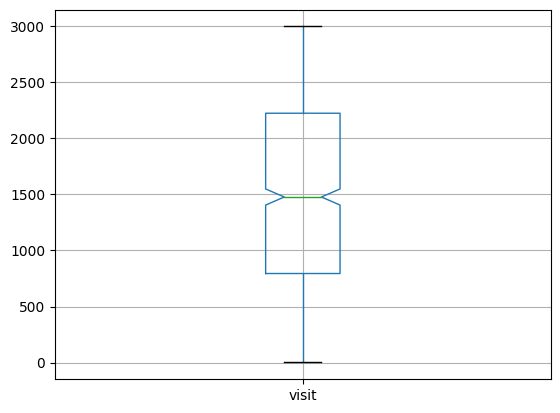

In [137]:
# 6. Create a box plot to check for outliers.
# First checking for outliers creating box plot with matplotlib
import matplotlib.pyplot as plt
visit_data.boxplot('visit',notch=True)
plt.show()


In [138]:
# 7. Get rid of any outliers.
df_after = visit_data[(visit_data[column] >= lower_bound) & (visit_data[column] <= upper_bound)]  
# Removing the rows where visits are out of the IGR
print("New size (Rows and Columns) - {}".format(df_after.shape))

New size (Rows and Columns) - (974, 7)


## 3. Insert data into a SQL Lite database – 

create a table with the following data below that you will create yourself 

(Hint on how to create the SQL: Python for Data Analysis 2nd edition page 191, Python for Data Analysis 3rd Edition: Page 199):



   a. Name, Address, City, State, Zip, Phone Number

   b. Add at least 10 rows of data and submit your code with a query generating your results.



In [141]:
# a. Creating database file named contacts_data.db
import sqlite3

# Connect to SQLite. Creating the file.
conn = sqlite3.connect('contacts_data.db')
cursor = conn.cursor()

In [143]:
# Creating the table with the requested columns.
cursor.execute("""
CREATE TABLE IF NOT EXISTS contact_info (
    Name TEXT,
    Address TEXT,
    City TEXT,
    State TEXT,
    Zip TEXT,
    Phone_Number TEXT
)
""")

In [149]:
# b. Adding 10 rows of data and generating the results.
data = [
    ('Adam Strictland', '123 Apple St', 'Atlanta', 'GA', '30303', '470-456-7890'),
    ('Barbara Steisand', '234 Cherry St', 'Los Angeles', 'CA', '90005', '562-456-7832'),
    ('Charles Duval', '112 Pine Rd', 'Atlanta', 'GA', '30301', '678-562-7756'),
    ('Haley Smith', '623 Bay St', 'Seattle', 'WA', '98101', '206-562-4563'),
    ('Ian Wright', '532 Elm Dr', 'Boston', 'MA', '02108', '617-856-9546'),
    ('Cindy Laughland', '90 Cedar Ln', 'Chicago', 'IL', '60601', '312-232-4562'),
    ('Hannah Montana', '560 Birch Blvd', 'Denver', 'CO', '80201', '856-321-7569'),
    ('Jane Doe', '44 Walnut Ct', 'Austin', 'TX', '78701', '956-456-3214'),
    ('James Taylor', '25 Spruce St', 'Miami', 'FL', '33101', '102-326-7896'),
    ('Thomas Myller', '772 Aspen Way', 'Portland', 'OR', '97201', '956-654-6548')
]

In [150]:
# inserting data
cursor.executemany("INSERT INTO contact_info VALUES (?,?,?,?,?,?)", data)

# Commitng changes to the database
conn.commit()

In [151]:
# creating query and running it to show result
query = "SELECT * FROM contact_info"
df_results = pd.read_sql(query, conn)
print("Results from SQLite Database")
print(df_results)

Results from SQLite Database
                Name         Address         City State    Zip  Phone_Number
0    Adam Strictland    123 Apple St      Atlanta    GA  30303  123-456-7890
1   Barbara Steisand   234 Cherry St  Los Angeles    CA  90005  562-456-7832
2      Charles Duval     112 Pine Rd      Atlanta    GA  30301  678-562-7756
3        Haley Smith      623 Bay St      Seattle    WA  98101  206-562-4563
4         Ian Wright      532 Elm Dr       Boston    MA  02108  617-856-9546
5    Cindy Laughland     90 Cedar Ln      Chicago    IL  60601  312-232-4562
6     Hannah Montana  560 Birch Blvd       Denver    CO  80201  856-321-7569
7           Jane Doe    44 Walnut Ct       Austin    TX  78701  956-456-3214
8       James Taylor    25 Spruce St        Miami    FL  33101  102-326-7896
9      Thomas Myller   772 Aspen Way     Portland    OR  97201  956-654-6548
10   Adam Strictland    123 Apple St      Atlanta    GA  30303  470-456-7890
11  Barbara Steisand   234 Cherry St  Los Angel